# <b><u><i>Stress Level Dataset ----</b></i></u>

In [48]:
# FOR PATH RECOGNISION ----

from pathlib import Path

print("Current Folder:")
print(Path.cwd())

print("\nParent:")
print(Path.cwd().parent)

Current Folder:
c:\Users\mohit\OneDrive\Desktop\Calmify AI\Calmify_AI\Calmify_AI\notebooks\Stress Level Dataset

Parent:
c:\Users\mohit\OneDrive\Desktop\Calmify AI\Calmify_AI\Calmify_AI\notebooks


In [2]:
# IGNORING WARNINGS --

import warnings

warnings.filterwarnings("ignore")

In [3]:
# IMPORTING ALL NECESSARY LIBRARIES --

# Data Handling

import pandas as pd
import numpy as np

# Visualization

import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing

from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler,
    MinMaxScaler
)

# Train Test Split

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    cross_val_score
)

# Models

from sklearn.ensemble import (
    RandomForestClassifier,
    RandomForestRegressor
)

from xgboost import (
    XGBClassifier,
    XGBRegressor
)

# Evaluation

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Model Saving

import joblib

# Display

pd.set_option(
    "display.max_columns",
    None
)

print("all the necessary libraries are imported sucessfully:")
print("🎉🎉🎉🎉")

all the necessary libraries are imported sucessfully:
🎉🎉🎉🎉


In [4]:
# loading dataset --

from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path.cwd().parents[1]

DATASET_DIR = PROJECT_ROOT / "datasets"
MODEL_DIR = PROJECT_ROOT / "notebooks" / "models"
PREPROCESS_DIR = PROJECT_ROOT / "notebooks" / "preprocessing"

MODEL_DIR.mkdir(exist_ok=True)
PREPROCESS_DIR.mkdir(exist_ok=True)

df = pd.read_csv(
    DATASET_DIR / "StressLevelDataset.csv"
)

print("FINALLY: 🏅🏅")
df.head()

FINALLY: 🏅🏅


,anxiety_level,self_esteem,mental_health_history,depression,headache,blood_pressure,sleep_quality,breathing_problem,noise_level,living_conditions,safety,basic_needs,academic_performance,study_load,teacher_student_relationship,future_career_concerns,social_support,peer_pressure,extracurricular_activities,bullying,stress_level
0,14,20,0,11,2,1,2,4,2,3,3,2,3,2,3,3,2,3,3,2,1
1,15,8,1,15,5,3,1,4,3,1,2,2,1,4,1,5,1,4,5,5,2
2,12,18,1,14,2,1,2,2,2,2,3,2,2,3,3,2,2,3,2,2,1
3,16,12,1,15,4,3,1,3,4,2,2,2,2,4,1,4,1,4,4,5,2
4,16,28,0,7,2,3,5,1,3,2,4,3,4,3,1,2,1,5,0,5,1


In [5]:
# SHAPE OF DATASET --

print(df.shape)

(1100, 21)


In [6]:
# INFORMATION OF DATASET --

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1100 entries, 0 to 1099
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype
---  ------                        --------------  -----
 0   anxiety_level                 1100 non-null   int64
 1   self_esteem                   1100 non-null   int64
 2   mental_health_history         1100 non-null   int64
 3   depression                    1100 non-null   int64
 4   headache                      1100 non-null   int64
 5   blood_pressure                1100 non-null   int64
 6   sleep_quality                 1100 non-null   int64
 7   breathing_problem             1100 non-null   int64
 8   noise_level                   1100 non-null   int64
 9   living_conditions             1100 non-null   int64
 10  safety                        1100 non-null   int64
 11  basic_needs                   1100 non-null   int64
 12  academic_performance          1100 non-null   int64
 13  study_load                    110

In [7]:
# DESCRIPTION OF DATASET --

df.describe()

,anxiety_level,self_esteem,mental_health_history,depression,headache,blood_pressure,sleep_quality,breathing_problem,noise_level,living_conditions,safety,basic_needs,academic_performance,study_load,teacher_student_relationship,future_career_concerns,social_support,peer_pressure,extracurricular_activities,bullying,stress_level
count,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000
mean,11.063636,17.777273,0.492727,12.555455,2.508182,2.181818,2.660000,2.753636,2.649091,2.518182,2.737273,2.772727,2.772727,2.621818,2.648182,2.649091,1.881818,2.734545,2.767273,2.617273,0.996364
std,6.117558,8.944599,0.500175,7.727008,1.409356,0.833575,1.548383,1.400713,1.328127,1.119208,1.406171,1.433761,1.414594,1.315781,1.384579,1.529375,1.047826,1.425265,1.417562,1.530958,0.821673
min,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,6.000000,11.000000,0.000000,6.000000,1.000000,1.000000,1.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000,1.000000,2.000000,2.000000,1.000000,0.000000
50%,11.000000,19.000000,0.000000,12.000000,3.000000,2.000000,2.500000,3.000000,3.000000,2.000000,2.000000,3.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.500000,3.000000,1.000000
75%,16.000000,26.000000,1.000000,19.000000,3.000000,3.000000,4.000000,4.000000,3.000000,3.000000,4.000000,4.000000,4.000000,3.000000,4.000000,4.000000,3.000000,4.000000,4.000000,4.000000,2.000000
max,21.000000,30.000000,1.000000,27.000000,5.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,3.000000,5.000000,5.000000,5.000000,2.000000


In [8]:
# COLUMNS LIST --

df.columns.tolist()

['anxiety_level',
 'self_esteem',
 'mental_health_history',
 'depression',
 'headache',
 'blood_pressure',
 'sleep_quality',
 'breathing_problem',
 'noise_level',
 'living_conditions',
 'safety',
 'basic_needs',
 'academic_performance',
 'study_load',
 'teacher_student_relationship',
 'future_career_concerns',
 'social_support',
 'peer_pressure',
 'extracurricular_activities',
 'bullying',
 'stress_level']

In [9]:
# NULL VALUES --

a = df.isnull().sum()

if a.sum() > 0:
    print(a[a > 0])  
else:
    print("NO NULL VALUES:😁")


NO NULL VALUES:😁


In [10]:
# DUPLICATE VALUES --

a = df.duplicated().sum()

if a > 0:
    print("a")
else:
    print("NO DUPLICATES:✅✅")

NO DUPLICATES:✅✅


In [11]:
# TARGET FEATURE --

df["stress_level"].value_counts()

stress_level
0    373
2    369
1    358
Name: count, dtype: int64

In [12]:
# FEATURE ENGGINEERING ----

df["mental_health_score"] = (
    df["anxiety_level"] +
    df["depression"]
)

df["academic_stress_score"] = (
    df["study_load"] +
    (5 - df["academic_performance"]) +
    df["future_career_concerns"]
)

df["environment_score"] = (
    df["noise_level"] +
    (5 - df["safety"]) +
    (5 - df["living_conditions"])
)

df["physical_health_score"] = (
    df["headache"] +
    df["breathing_problem"] +
    df["blood_pressure"]
)

df["support_score"] = (
    df["social_support"] +
    df["teacher_student_relationship"]
)

df["risk_score"] = (
    df["mental_health_score"] +
    df["academic_stress_score"] +
    df["environment_score"]
)

# <B><I><U>EDA --</B></U></I>

In [18]:

sns.set_style("whitegrid")

In [19]:
#BASIC OVERVIEW --

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 1100
Columns: 27


In [21]:
# TARGET DISTRIBUTION --

df["stress_level"].value_counts()

stress_level
0    373
2    369
1    358
Name: count, dtype: int64

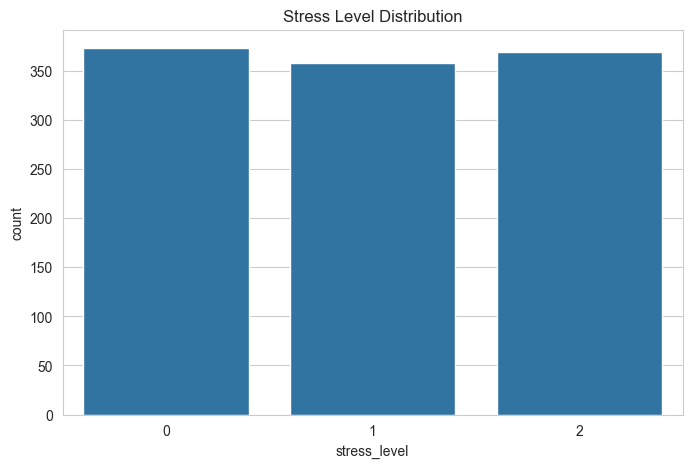

In [20]:
# STRESS LEVEL VISUALISATION --

plt.figure(figsize=(8,5))

sns.countplot(
    x="stress_level",
    data=df
)

plt.title(
    "Stress Level Distribution"
)

plt.show()

In [22]:
# CLASS PERCENTAGE --

(
    df["stress_level"]
    .value_counts(normalize=True)
    * 100
)

stress_level
0    33.909091
2    33.545455
1    32.545455
Name: proportion, dtype: float64

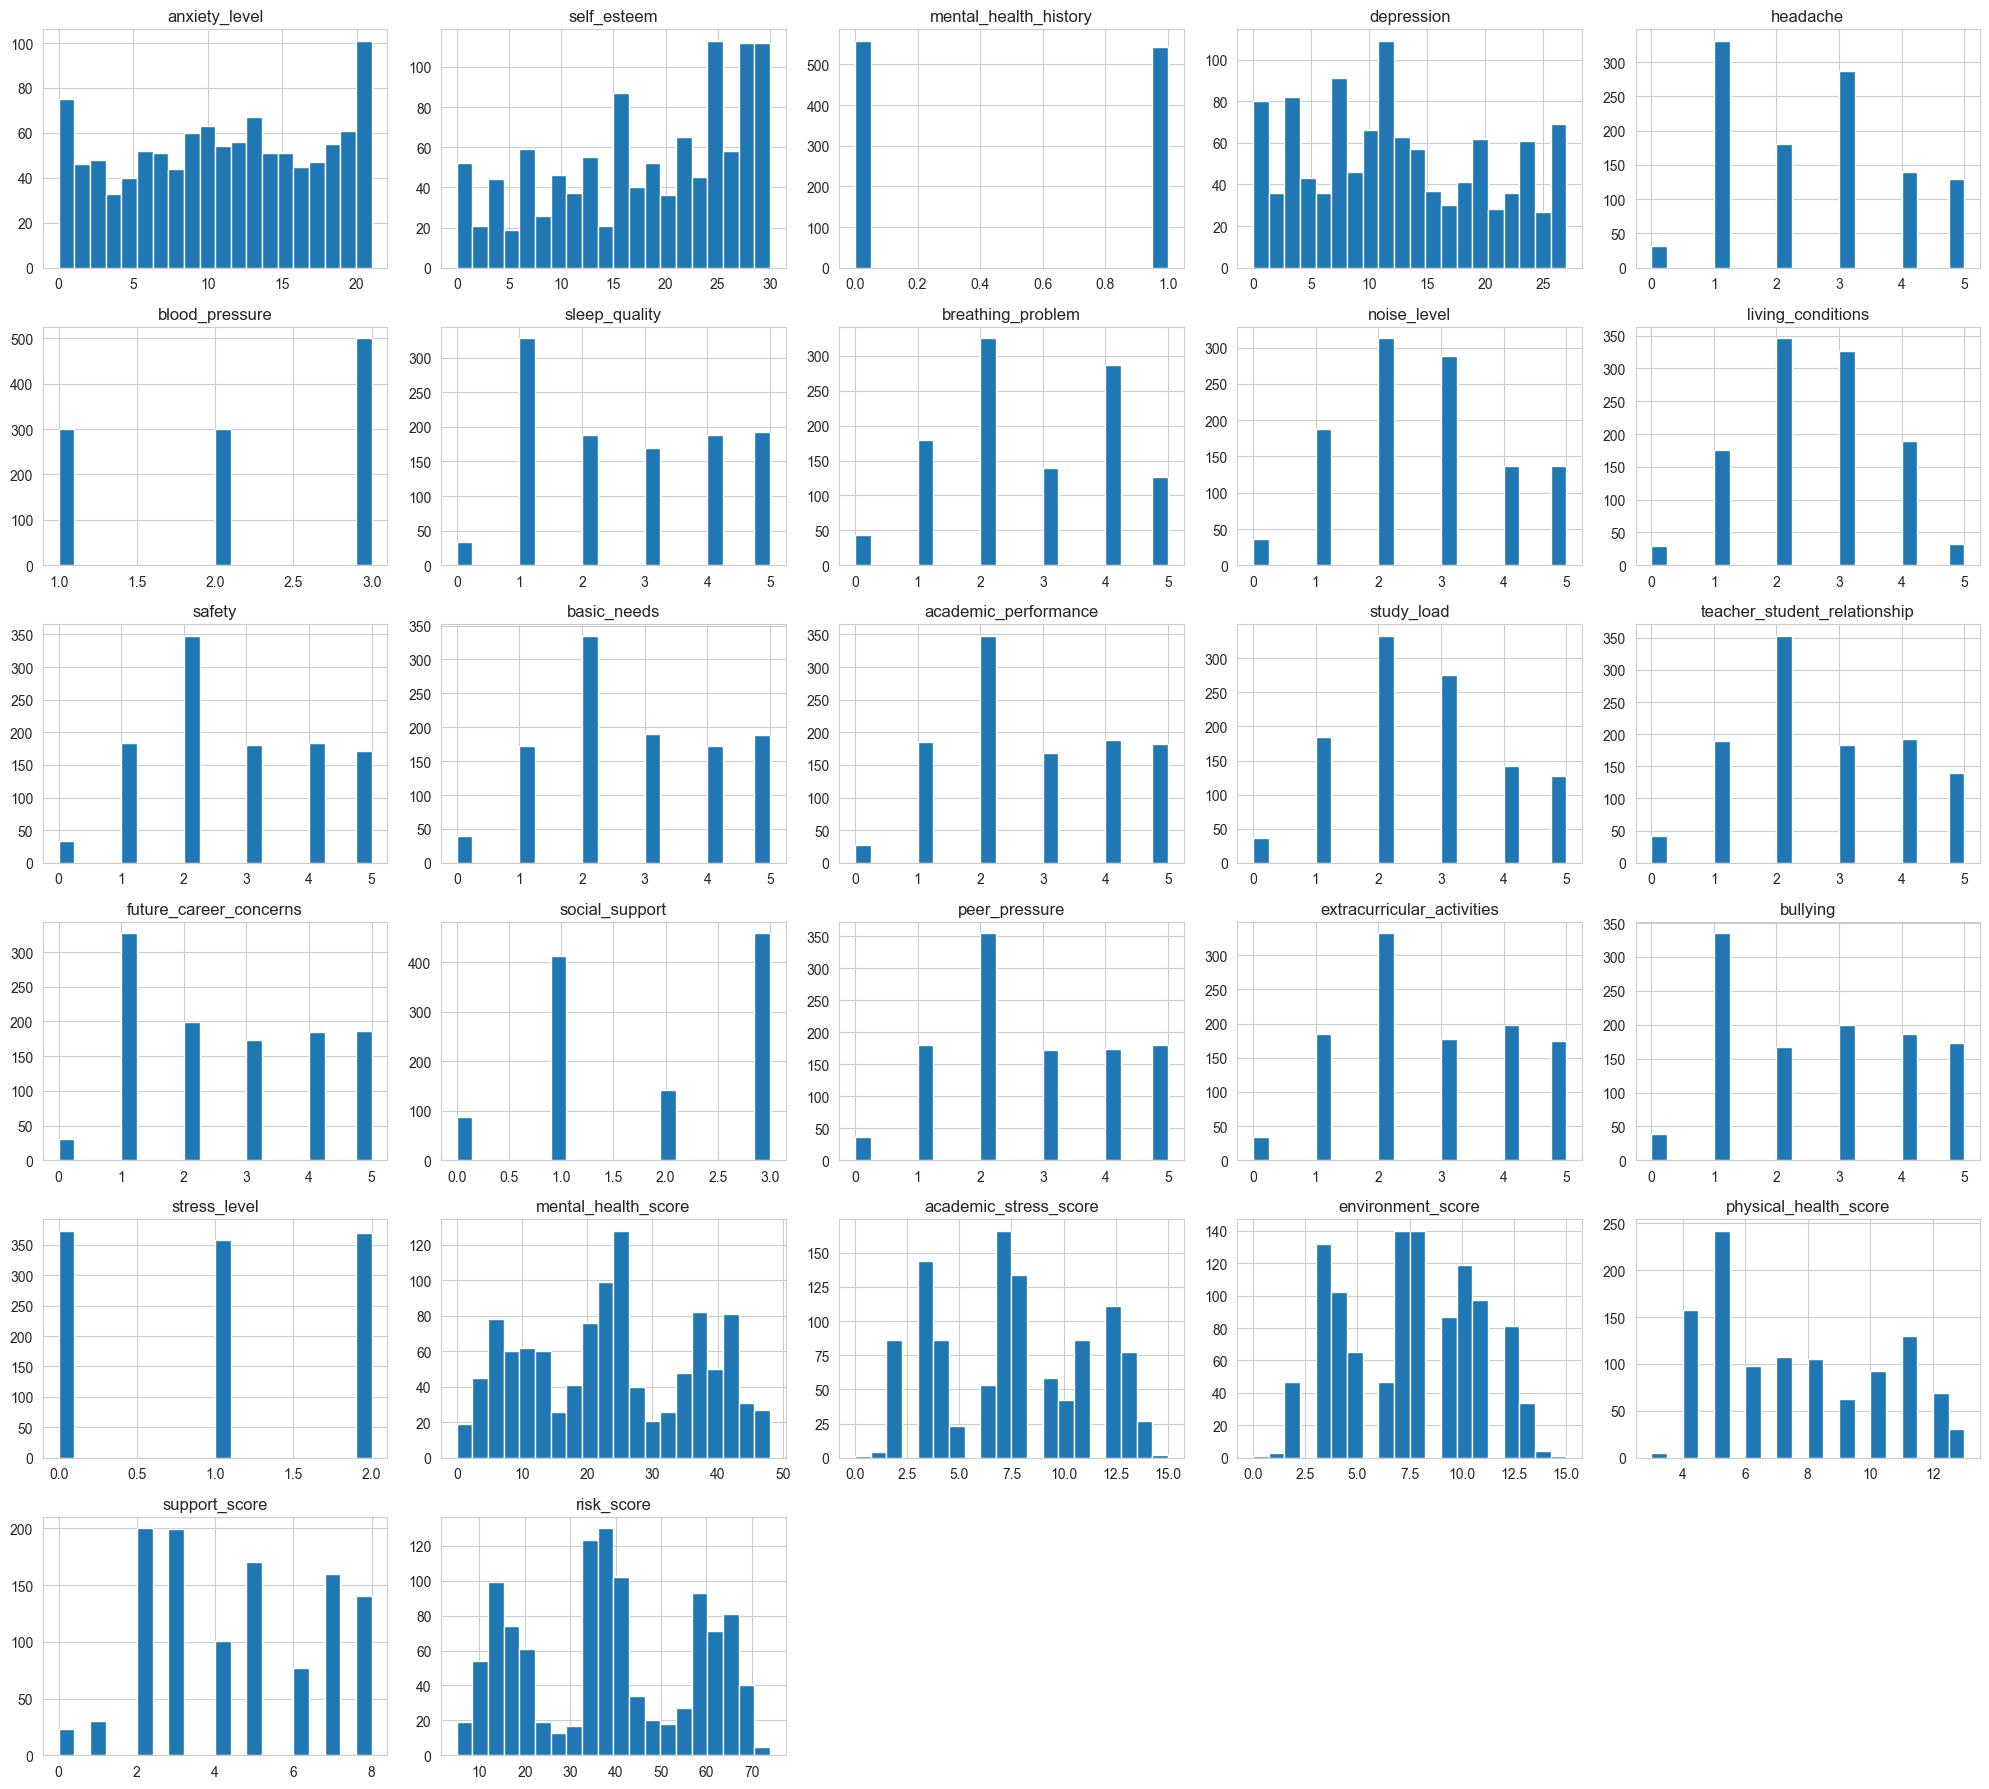

In [23]:
# ALL FEATURES DISTRIBUTION --

df.hist(
    figsize=(20,18),
    bins=20
)

plt.tight_layout()

plt.show()

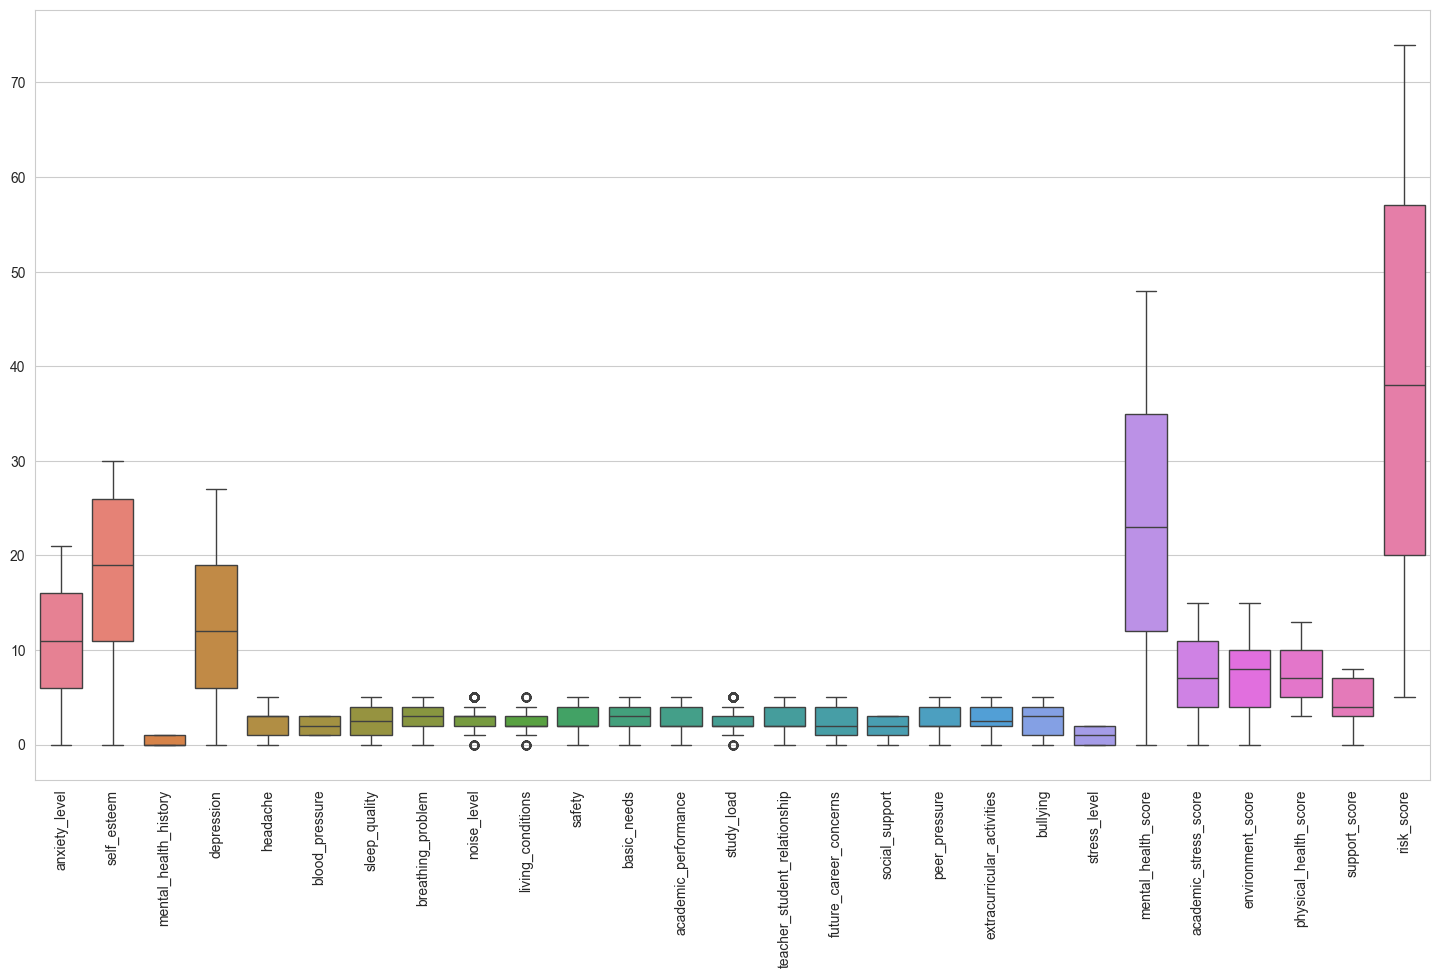

In [24]:
plt.figure(figsize=(18,10))

sns.boxplot(
    data=df
)

plt.xticks(
    rotation=90
)

plt.show()

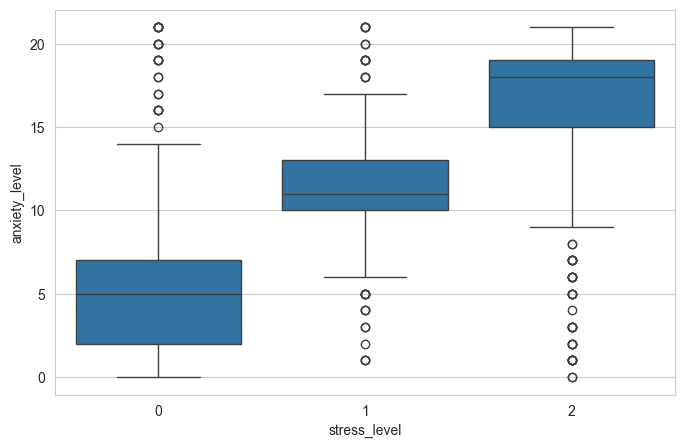

In [25]:
# STRESS V/S ANXIETY --

plt.figure(figsize=(8,5))

sns.boxplot(
    x="stress_level",
    y="anxiety_level",
    data=df
)

plt.show()

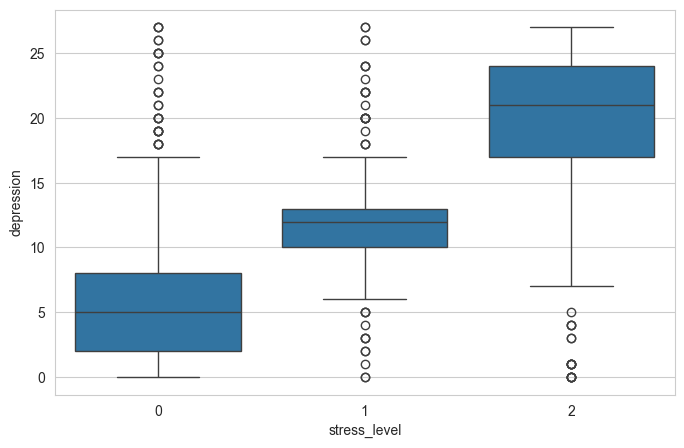

In [27]:
# STRESS V/S DEPRESSION --

plt.figure(figsize=(8,5))

sns.boxplot(
    x="stress_level",
    y="depression",
    data=df
)

plt.show()

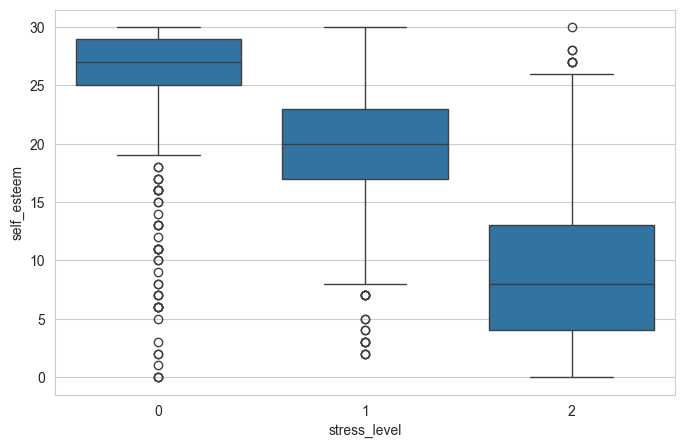

In [28]:
# STRESS LEVEL V/S SELF_ESTEEM --

plt.figure(figsize=(8,5))

sns.boxplot(
    x="stress_level",
    y="self_esteem",
    data=df
)

plt.show()

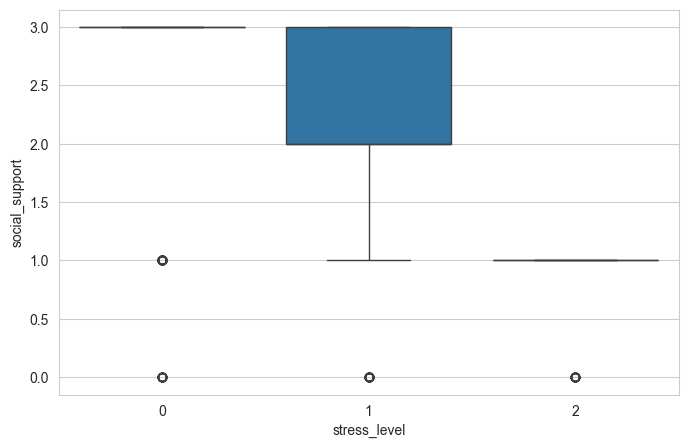

In [29]:
# STRESS LEVEL V/S SOCIAL SUPPORT --

plt.figure(figsize=(8,5))

sns.boxplot(
    x="stress_level",
    y="social_support",
    data=df
)

plt.show()

# <B><U><I>CORRELATION</U> ----</B></I>

In [30]:
# CORRELATION MAYRIX --

corr_matrix = df.corr()

corr_matrix

,anxiety_level,self_esteem,mental_health_history,depression,headache,blood_pressure,sleep_quality,breathing_problem,noise_level,living_conditions,safety,basic_needs,academic_performance,study_load,teacher_student_relationship,future_career_concerns,social_support,peer_pressure,extracurricular_activities,bullying,stress_level,mental_health_score,academic_stress_score,environment_score,physical_health_score,support_score,risk_score
anxiety_level,1.000000,-0.672745,0.634450,0.694340,0.632738,0.330867,-0.710292,0.561654,0.608624,-0.568434,-0.651220,-0.637079,-0.649601,0.586064,-0.663176,0.717016,-0.569748,0.642910,0.641022,0.709982,0.736795,0.900019,0.769543,0.742050,0.704470,-0.678181,0.896343
self_esteem,-0.672745,1.000000,-0.603502,-0.699602,-0.626058,-0.514692,0.662693,-0.510514,-0.571169,0.550535,0.643981,0.631212,0.639045,-0.575112,0.652934,-0.712520,0.679211,-0.607118,-0.641202,-0.640737,-0.756195,-0.746289,-0.759540,-0.716912,-0.730492,0.723170,-0.784364
mental_health_history,0.634450,-0.603502,1.000000,0.615882,0.604826,0.295617,-0.614146,0.464347,0.515290,-0.508525,-0.546731,-0.601196,-0.586193,0.532267,-0.587728,0.625909,-0.482560,0.580602,0.554576,0.624366,0.648644,0.677222,0.686747,0.635804,0.630565,-0.590534,0.708754
depression,0.694340,-0.699602,0.615882,1.000000,0.657700,0.436084,-0.693161,0.522540,0.566250,-0.530351,-0.625857,-0.608776,-0.633174,0.602498,-0.673853,0.706561,-0.617972,0.635544,0.648551,0.665790,0.734379,0.938578,0.764681,0.699743,0.729018,-0.707413,0.914657
headache,0.632738,-0.626058,0.604826,0.657700,1.000000,0.361986,-0.638771,0.461719,0.543557,-0.532825,-0.589136,-0.623199,-0.622059,0.542890,-0.625928,0.679307,-0.572988,0.622581,0.582562,0.609775,0.713484,0.701727,0.727170,0.674905,0.849945,-0.656617,0.740200
blood_pressure,0.330867,-0.514692,0.295617,0.436084,0.361986,1.000000,-0.300323,0.162308,0.352744,-0.274686,-0.288354,-0.280590,-0.262785,0.348964,-0.352123,0.434087,-0.752531,0.401392,0.426254,0.370440,0.394200,0.422761,0.412789,0.371423,0.566342,-0.571140,0.434970
sleep_quality,-0.710292,0.662693,-0.614146,-0.693161,-0.638771,-0.300323,1.000000,-0.541687,-0.576645,0.535462,0.657686,0.620955,0.671326,-0.551775,0.677569,-0.682130,0.554553,-0.649098,-0.623092,-0.699427,-0.749068,-0.760391,-0.750836,-0.719954,-0.688275,0.679974,-0.792884
breathing_problem,0.561654,-0.510514,0.464347,0.522540,0.461719,0.162308,-0.541687,1.000000,0.459235,-0.448997,-0.519348,-0.508172,-0.507251,0.428791,-0.498895,0.545345,-0.365173,0.492729,0.516884,0.576341,0.573984,0.585784,0.584284,0.579345,0.788268,-0.480431,0.616197
noise_level,0.608624,-0.571169,0.515290,0.566250,0.543557,0.352744,-0.576645,0.459235,1.000000,-0.452362,-0.536630,-0.572327,-0.513730,0.493625,-0.538758,0.575439,-0.492094,0.583817,0.563614,0.585458,0.663371,0.634779,0.623083,0.813969,0.614022,-0.564659,0.697686
living_conditions,-0.568434,0.550535,-0.508525,-0.530351,-0.532825,-0.274686,0.535462,-0.448997,-0.452362,1.000000,0.563571,0.503275,0.507221,-0.437732,0.549332,-0.565071,0.466594,-0.501795,-0.515794,-0.551139,-0.581723,-0.593766,-0.595852,-0.789909,-0.579945,0.559252,-0.660043


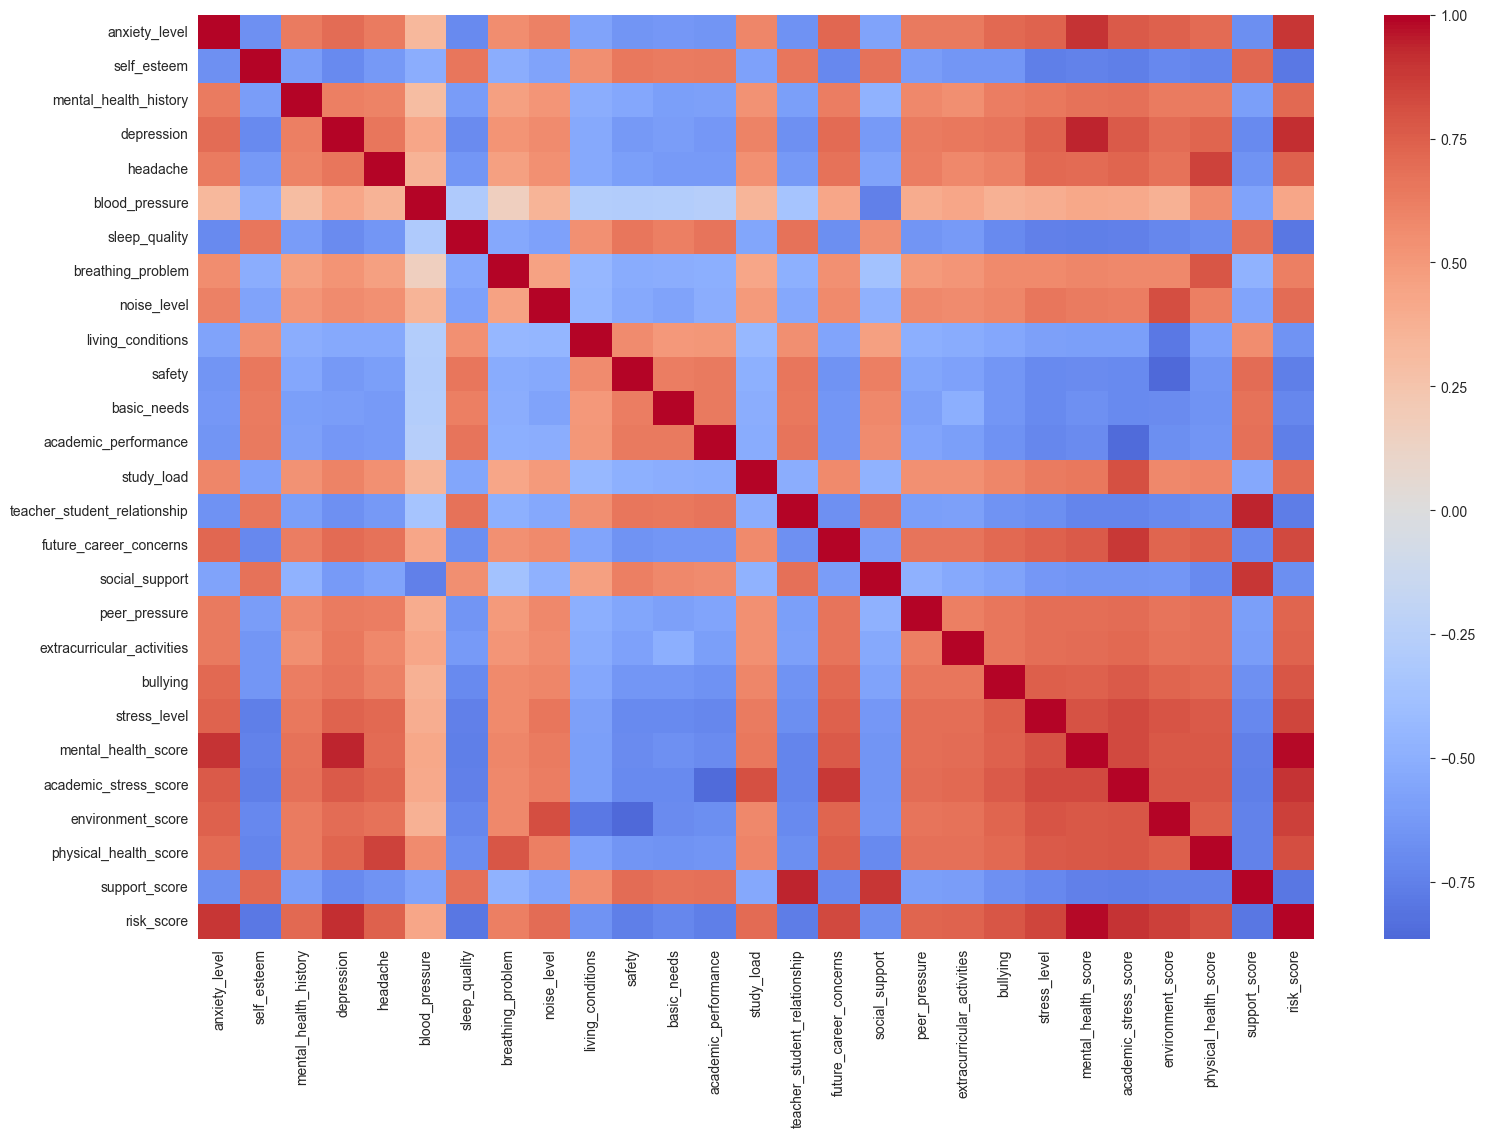

In [31]:
# HEATMAP --

plt.figure(
    figsize=(18,12)
)

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0
)

plt.show()

In [32]:
# WITH TARGET --

target_corr = (
    corr_matrix["stress_level"]
    .sort_values(
        ascending=False
    )
)

target_corr

stress_level                    1.000000
risk_score                      0.846335
academic_stress_score           0.825692
mental_health_score             0.798063
environment_score               0.795396
physical_health_score           0.770749
bullying                        0.751162
future_career_concerns          0.742619
anxiety_level                   0.736795
depression                      0.734379
headache                        0.713484
extracurricular_activities      0.692977
peer_pressure                   0.690684
noise_level                     0.663371
mental_health_history           0.648644
study_load                      0.634156
breathing_problem               0.573984
blood_pressure                  0.394200
living_conditions              -0.581723
social_support                 -0.632497
teacher_student_relationship   -0.680163
basic_needs                    -0.708968
safety                         -0.709602
support_score                  -0.718136
academic_perform

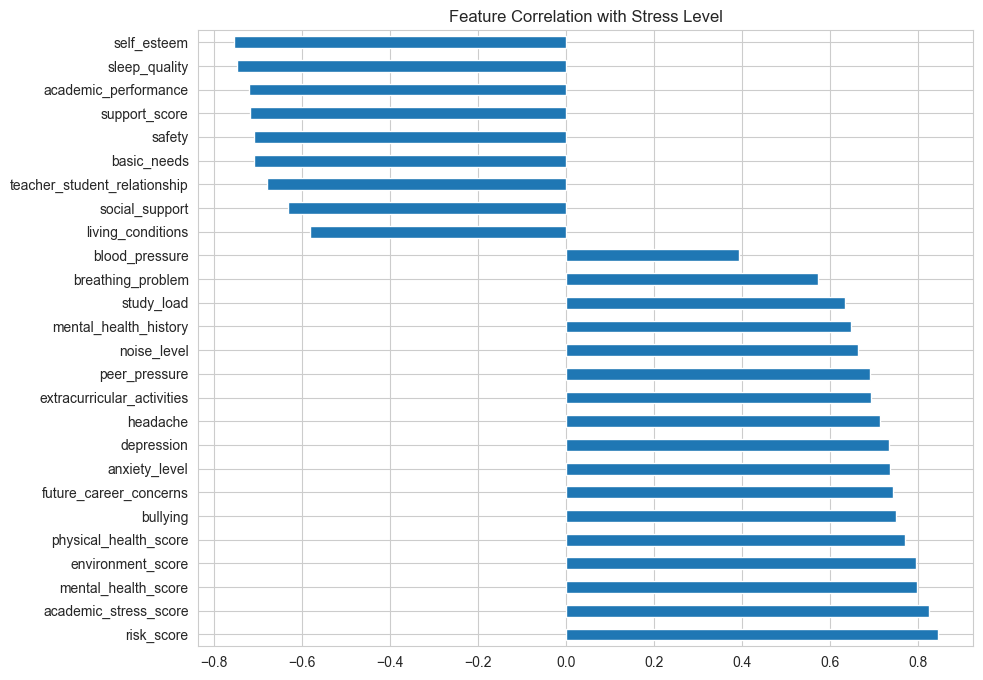

In [33]:
# TARGET BOXPLOT --

plt.figure(
    figsize=(10,8)
)

target_corr.drop(
    "stress_level"
).plot(
    kind="barh"
)

plt.title(
    "Feature Correlation with Stress Level"
)

plt.show()

In [34]:
# Top Positive Features --

target_corr[
    target_corr > 0]

stress_level                  1.000000
risk_score                    0.846335
academic_stress_score         0.825692
mental_health_score           0.798063
environment_score             0.795396
physical_health_score         0.770749
bullying                      0.751162
future_career_concerns        0.742619
anxiety_level                 0.736795
depression                    0.734379
headache                      0.713484
extracurricular_activities    0.692977
peer_pressure                 0.690684
noise_level                   0.663371
mental_health_history         0.648644
study_load                    0.634156
breathing_problem             0.573984
blood_pressure                0.394200
Name: stress_level, dtype: float64

In [35]:
# Top Negative Features --

target_corr[
    target_corr < 0
]

living_conditions              -0.581723
social_support                 -0.632497
teacher_student_relationship   -0.680163
basic_needs                    -0.708968
safety                         -0.709602
support_score                  -0.718136
academic_performance           -0.720922
sleep_quality                  -0.749068
self_esteem                    -0.756195
Name: stress_level, dtype: float64

In [37]:
# IMPORTANT FEATURES --

top_features = (
    target_corr.abs()
    .sort_values(
        ascending=False
    )
    .head(10)
)

top_features

stress_level              1.000000
risk_score                0.846335
academic_stress_score     0.825692
mental_health_score       0.798063
environment_score         0.795396
physical_health_score     0.770749
self_esteem               0.756195
bullying                  0.751162
sleep_quality             0.749068
future_career_concerns    0.742619
Name: stress_level, dtype: float64

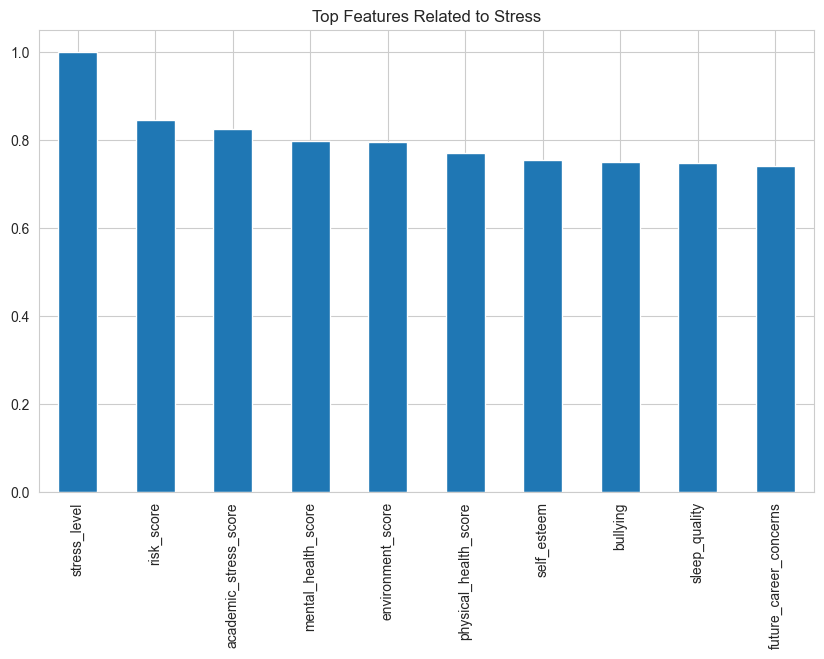

In [38]:
plt.figure(
    figsize=(10,6)
)

top_features.plot(
    kind="bar"
)

plt.title(
    "Top Features Related to Stress"
)

plt.show()

In [41]:
from pathlib import Path

PREPROCESS_DIR = Path("../preprocessed")

PREPROCESS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

In [42]:
target_corr.to_csv(
    PREPROCESS_DIR /
    "stress_correlation.csv"
)

# <B><U><I> FEATURE EXTRACTION</U> ----</B></I>

In [44]:
# DROPPING UNNECESSARY COLUMNS --

drop_cols = [

    "stress_level",

    "risk_score",

    "academic_stress_score",

    "mental_health_score",

    "environment_score",

    "physical_health_score",

    "support_score"

]

In [45]:
# FINAL FEATURES --

X = df.drop(
    columns=drop_cols
)

y = df["stress_level"]

In [46]:
print(X.shape)
print(y.shape)

(1100, 20)
(1100,)


In [47]:
df.to_csv(
    PREPROCESS_DIR /
    "stress_cleaned.csv",
    index=False
)

print(
    "Stress dataset saved successfully"
)

Stress dataset saved successfully
